### Demonstrate how *eigenfaces* can be rendered as appliaction of PCA

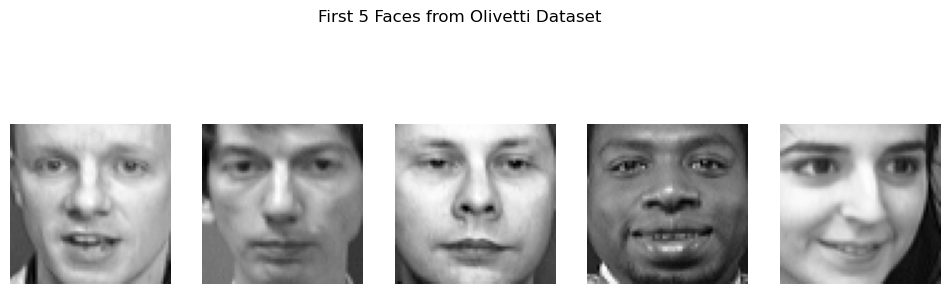

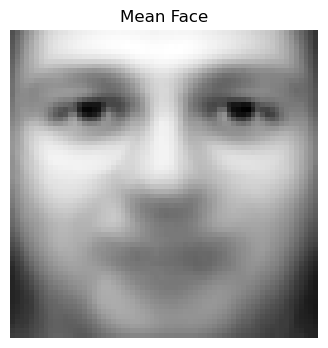

In [16]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X = faces.data
y = faces.target
images = faces.images
n_samples, h, w = images.shape

# Display the first 5 faces
fig, axes = plt.subplots(1, 5, figsize=(12, 4))
for i, ax in enumerate(axes):
    ax.imshow(images[i], cmap='gray')
    ax.axis('off')
plt.suptitle('First 5 Faces from Olivetti Dataset')
plt.show()

# Display the mean face
mean_face = X.mean(axis=0).reshape((h, w))
plt.figure(figsize=(4, 4))
plt.imshow(mean_face, cmap='gray')
plt.title('Mean Face')
plt.axis('off')
plt.show()


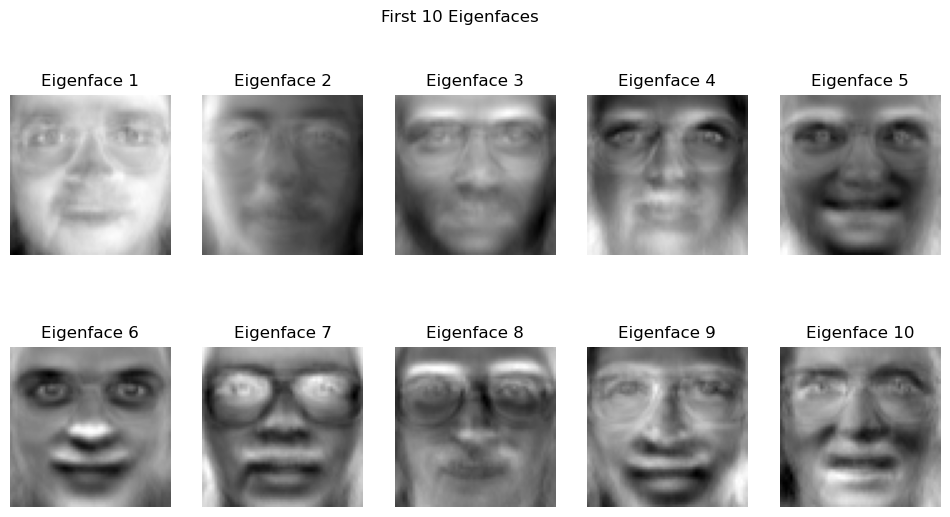

In [17]:
# Fit PCA to Olivetti faces and examine eigenfaces
n_components = 50
pca = PCA(n_components=n_components, whiten=True, random_state=42)
pca.fit(X)

# Plot the first 10 eigenfaces
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape((h, w)), cmap='gray')
    ax.set_title(f'Eigenface {i+1}')
    ax.axis('off')
plt.suptitle('First 10 Eigenfaces')
plt.show()


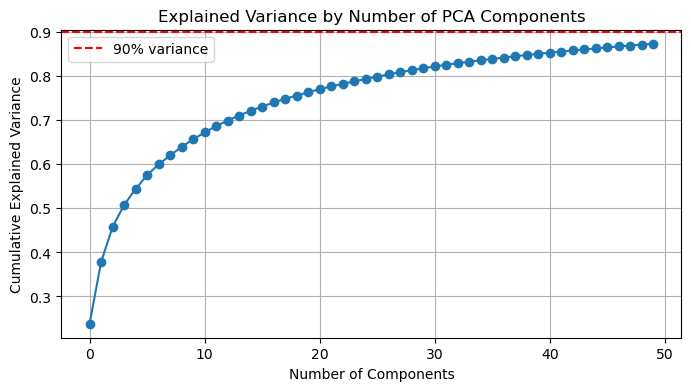

Number of components for 90% variance: 50


In [27]:
# Plot the cumulative explained variance ratio
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Number of PCA Components')
plt.grid(True)
plt.axhline(0.9, color='red', linestyle='--', label='90% variance')
plt.legend()
plt.show()

print(f'Number of components for 90% variance: {np.searchsorted(np.cumsum(pca.explained_variance_ratio_), 0.9)}')


In [19]:
from ipywidgets import interact, IntSlider

# Interactive reconstruction of a single face using a variable number of eigenfaces

def show_reconstruction(image_index=0, n_components=10):
    pca = PCA(n_components=n_components, whiten=True, random_state=42).fit(X)
    reconstructed = pca.inverse_transform(pca.transform(X[image_index:image_index+1]))
    
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(images[image_index], cmap='gray')
    plt.title('Original Face')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed.reshape((h, w)), cmap='gray')
    plt.title(f'Reconstruction with {n_components} components')
    plt.axis('off')
    
    plt.show()

interact(
    show_reconstruction,
    image_index=IntSlider(min=0, max=n_samples - 1, step=1, value=0),
    n_components=IntSlider(min=1, max=100, step=1, value=20),
)


interactive(children=(IntSlider(value=0, description='image_index', max=399), IntSlider(value=20, description=…

<function __main__.show_reconstruction(image_index=0, n_components=10)>